In [1]:
DATASET_NAME = "mimic_iv_cohort"
TEST_SIZE = 0.2
SEED = 4

In [2]:
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
  from google.colab import userdata
  from google.colab import drive
  drive.mount('/content/drive')
  PROJECT_ROOT = userdata.get('PROJECT_ROOT')
else:
  PROJECT_ROOT = '..'
  SRC = f"{PROJECT_ROOT}/src"
  if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)
  if SRC not in sys.path:
    sys.path.append(SRC)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from config import Config

In [4]:

cohort = pd.read_csv(f"{PROJECT_ROOT}/{Config.DATA_DIR}/{DATASET_NAME}.csv")

In [5]:
print(f"Current features: {cohort.shape[1] - 1}")
print(f"Current population: {cohort.shape[0]}")

Current features: 70
Current population: 13890


# Missingness

- Remove features with more than 25% missing values
- Remove rows with more than 20% features missing
- Multivariate imputer for remaining missing values (in the training loop, stratified by ethnicity)

## Drop columns

In [6]:
# Drop columns with > 25% missing values in any ethnicity subgroup
missing_ratio = cohort.isna().mean()
subgroup_missing = cohort.isna().groupby(cohort['race_group']).mean()

cols_to_drop = list(set(missing_ratio[missing_ratio > 0.25].index.tolist() + subgroup_missing.columns[(subgroup_missing > 0.25).any()].tolist()))

study_dataset = cohort.drop(columns=cols_to_drop)

print(f"Dropped {len(cols_to_drop)} columns: {cols_to_drop}")
print(f"Remaining features: {study_dataset.shape[1] - 1}")
print(f"Current population: {study_dataset.shape[0]}")

Dropped 9 columns: ['fio2_max', 'ntbnp_max', 'ck_mb_max', 'ck_cpk_min', 'pao2_min', 'ck_cpk_max', 'ck_mb_min', 'ntbnp_min', 'bilirubin_max']
Remaining features: 61
Current population: 13890


## Sieve analysis

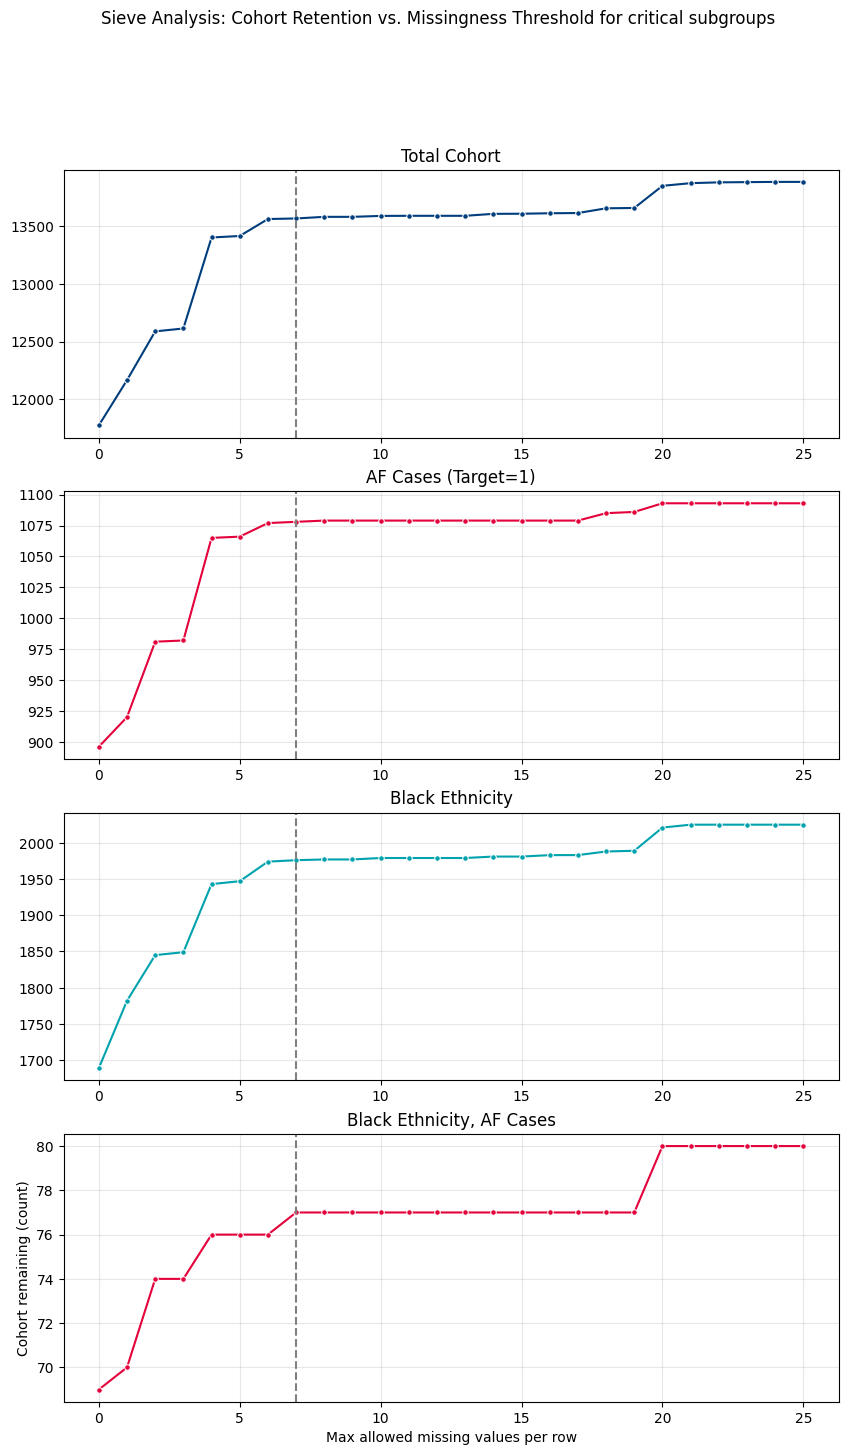

In [7]:
df_af = study_dataset[study_dataset['target_noaf'] == 1]
df_non_white = study_dataset[study_dataset['race_group'] != 0]
df_non_white_af = df_non_white[df_non_white['target_noaf'] == 1]

groups = {
  'Total Cohort': study_dataset,
  'AF Cases (Target=1)': df_af,
  'Black Ethnicity': df_non_white,
  'Black Ethnicity, AF Cases': df_non_white_af
}

thresholds = range(0, 26)
results = {name: [] for name in groups.keys()}

for t in thresholds:
  for name, subset in groups.items():
    # Count how many in this subset have <= t missing values
    n_missing = subset.isna().sum(axis=1)
    n_retained = len(subset) - sum(n_missing > t)
    results[name].append(n_retained)

fig, axes = plt.subplots(4, 1, figsize=(10, 16))
colors = ['#003d7c', '#e4003a', '#00a3ad', '#e4003a']
ax_idx = [0, 1, 2, 3]

for (name, counts), color, ax in zip(results.items(), colors, ax_idx):
  sns.lineplot(x=thresholds, y=counts, color=color, marker='o', markersize=4, ax=axes[ax])
  axes[ax].axvline(x=7, color='gray', linestyle='--', label='Candidate Threshold (20)')
  axes[ax].grid(True, alpha=0.3)
  axes[ax].set_title(name)

plt.suptitle('Sieve Analysis: Cohort Retention vs. Missingness Threshold for critical subgroups')
plt.xlabel('Max allowed missing values per row')
plt.ylabel('Cohort remaining (count)')
plt.show()

# Interpretation:
# If the three lines stay close together, the missingness is non differential, 
# i.e. low quality rows are distributed evenly across the population 
# and can be dealt with without introducing selection bias
# If the Non-White and AF lines drop significantly faster than the global population => differential missingness
# => relax the threshold or use imputation to preserve sample diversity
# However, this can show how data processing might affect bias in datasets

## Drop rows

In [8]:
# Drop rows with more than 7% missing features before imputation
chosen_threshold = 0.07
max_missing = study_dataset.shape[1] * chosen_threshold

missing_per_row = study_dataset.isna().sum(axis=1)

study_dataset = study_dataset.loc[missing_per_row <= max_missing, :].copy()

print(f"Rows dropped: {(missing_per_row > max_missing).sum(axis=0)}")
print(f"Remaining cohort size: {len(study_dataset)}")
print(f"Features: {study_dataset.shape[1]}")
print("Class and ethinicity split:")
print(study_dataset.groupby(['target_noaf','race_group']).size())

Rows dropped: 487
Remaining cohort size: 13403
Features: 62
Class and ethinicity split:
target_noaf  race_group
0            0             10471
             1              1867
1            0               989
             1                76
dtype: int64


## Missingness matrix

<Axes: >

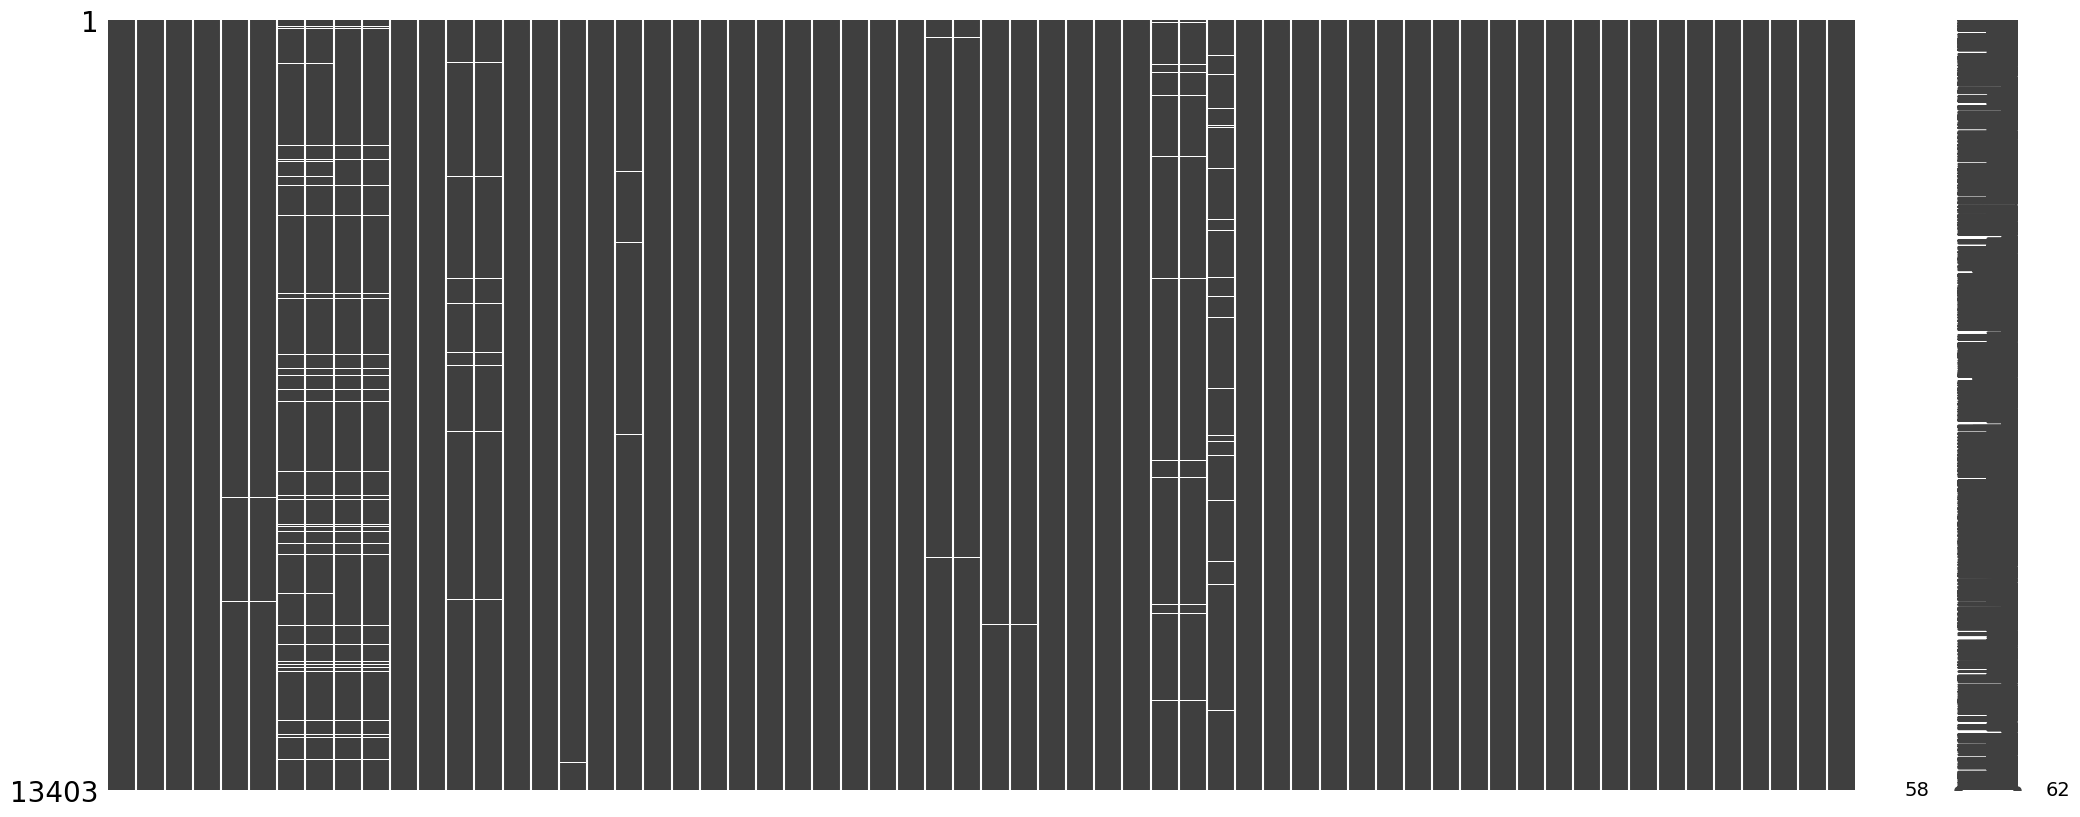

In [9]:
msno.matrix(study_dataset)

# Down sampling

In [10]:
print(pd.crosstab(study_dataset['race_group'], study_dataset['target_noaf']))

target_noaf      0    1
race_group             
0            10471  989
1             1867   76


In [11]:
def frequency_matched_sample(df, target_col='target_noaf', strata_cols=['gender', 'age_quantile', 'race_group']):
  """
  Performs 1:1 matching within each combined demographic and ethnic stratum.
  """
  matched_data = []
  
  # Group by Sex, Age, AND Ethnicity to ensure 1:1 matching within every subgroup
  for strata_values, group in df.groupby(strata_cols, observed=True):
    cases = group[group[target_col] == 1]
    controls = group[group[target_col] == 0]
    
    # Determine the number of pairs possible for this specific subgroup
    n_match = min(len(cases),len(controls))
    
    if n_match > 0:
      # Randomly sample to achieve 1:1 ratio
      sampled_cases = cases.sample(n_match, random_state=42)
      sampled_controls = controls.sample(n_match, random_state=42)
      
      matched_data.append(sampled_cases)
      matched_data.append(sampled_controls)
          
  return pd.concat(matched_data).reset_index(drop=True)

In [12]:
study_dataset['age_quantile'] = pd.qcut(study_dataset['admission_age'], q=4, labels=range(4))

balanced_dataset = frequency_matched_sample(study_dataset)

balanced_dataset.drop(['age_quantile'], axis=1, inplace=True)

print(f"Original Cohort Size: {len(study_dataset)}")
print(f"Balanced Cohort Size: {len(balanced_dataset)}")
print(f"Balanced AF Ratio: {balanced_dataset['target_noaf'].mean():.2%}")
print("\nMatched Case-Control counts by Ethnicity:")
print(pd.crosstab(balanced_dataset['race_group'], balanced_dataset['target_noaf']).to_markdown())

Original Cohort Size: 13403
Balanced Cohort Size: 2130
Balanced AF Ratio: 50.00%

Matched Case-Control counts by Ethnicity:
|   race_group |   0 |   1 |
|-------------:|----:|----:|
|            0 | 989 | 989 |
|            1 |  76 |  76 |


## TRAINING / TEST split

In [13]:
from sklearn.model_selection import train_test_split

strata = balanced_dataset[['target_noaf', 'race_group']]

train_df, test_df = train_test_split(
  balanced_dataset, 
  test_size=TEST_SIZE, 
  stratify=strata, 
  random_state=SEED
)

In [14]:
print(f"CEVAE-HE Training Set Size: {len(train_df)}")
print(f"CEVAE-HE Test and Classifier Bootstrap Set Size: {len(test_df)}")

print("\nTraining Set Ethnicity Distribution by Target Outcome:")
print(pd.crosstab(train_df['race_group'], train_df['target_noaf']).to_markdown())

print("\nTest Set Ethnicity Distribution by Target Outcome:")
print(pd.crosstab(test_df['race_group'], test_df['target_noaf']).to_markdown())

CEVAE-HE Training Set Size: 1704
CEVAE-HE Test and Classifier Bootstrap Set Size: 426

Training Set Ethnicity Distribution by Target Outcome:
|   race_group |   0 |   1 |
|-------------:|----:|----:|
|            0 | 791 | 791 |
|            1 |  61 |  61 |

Test Set Ethnicity Distribution by Target Outcome:
|   race_group |   0 |   1 |
|-------------:|----:|----:|
|            0 | 198 | 198 |
|            1 |  15 |  15 |


In [15]:
from tableone import TableOne

categorical_features = (
  ["target_noaf", "race_group", "gender"] + 
  [col for col in balanced_dataset.columns 
  if ((col.startswith('sofa_') and col != "sofa_total") 
      or col.startswith('comorb_') or col.startswith('gcs_'))] +
  ["vent_day1", "crrt_day1", "antibiotics_day1"])
continuous_features = [col for col in balanced_dataset.columns 
  if col not in categorical_features]

# Descriptive statistics
table1 = TableOne(balanced_dataset,
                  groupby='race_group',
                  continuous=continuous_features,
                  categorical=categorical_features,
                  normal_test=True,
                  tukey_test=True,
                  dip_test=True,
                  missing=True,
                  show_histograms=True
                  )

print(table1)

                                        Grouped by race_group                                                                                             
                                                      Missing          Overall                0                1 0 Histogram 1 Histogram Overall Histogram
n                                                                         2130             1978              152                                          
gender, n (%)                      0                               1156 (54.3)      1074 (54.3)        82 (53.9)                                          
                                   1                                974 (45.7)       904 (45.7)        70 (46.1)                                          
admission_age, mean (SD)                                    0      72.0 (12.2)      72.2 (12.0)      69.4 (14.4)    ▁▁▃▅█▇▇▅    ▂▁▁▃▅▆█▅          ▁▁▃▅█▇▇▆
hr_min, mean (SD)                                           0      69.

# Feature transformation

In [16]:
# Drop gcs scores, already embedded in the SOFA score
gcs_cols = [col for col in categorical_features 
  if (col.startswith('gcs_'))]

test_df.drop(columns=gcs_cols, inplace=True)
train_df.drop(columns=gcs_cols, inplace=True)

## Global Scaling

This is a conscious choice, as I need to train my CEVAE-HE before training my classifiers, and therefore need a consistently scaled dataset rather than applying scaling within bootstrapping loops

In [17]:
from scaling_utils import ZeroInflatedConditionalScaler, StrataAwareRobustScaler

sens_col = "race_group"

zero_inflated_features = [
  "max_norepinephrine_rate",
  "max_epinephrine_rate",
  "max_dopamine_rate"
]

multimodal_features = [col for col in continuous_features
  if col not in zero_inflated_features]

ordinal_scores = [col for col in categorical_features 
  if (col.startswith('sofa_'))]

scaled_train_df = train_df.copy()
scaled_test_df = test_df.copy()

In [18]:
zi_scaler = ZeroInflatedConditionalScaler(infusion_cols=zero_inflated_features)
scaled_train_df = zi_scaler.fit_transform(scaled_train_df)
scaled_test_df = zi_scaler.transform(scaled_test_df)

strata_scaler = StrataAwareRobustScaler(strata_col=sens_col, continuous_cols=multimodal_features)
scaled_train_df = strata_scaler.fit_transform(scaled_train_df)
scaled_test_df = strata_scaler.transform(scaled_test_df)

scaled_train_df, scaled_test_df = scaled_train_df.align(scaled_test_df, join='left', axis=1)

## Ordinal encoding

In [19]:
def encode_ordinal_scores(df):
    df_out = df.copy()
    for col in ordinal_scores:  
        # Create a binary indicator for each threshold step starting from 1 up to (max_val - 1)
        for threshold in range(0, 4):
            new_col_name = f"{col}_gt_{threshold}"
            df_out[new_col_name] = (df_out[col] >= threshold).astype(float)
        
        # Drop the original raw integer column
        df_out = df_out.drop(columns=[col])

    return df_out

scaled_train_df = encode_ordinal_scores(scaled_train_df)
scaled_test_df = encode_ordinal_scores(scaled_test_df)


In [20]:
# print(scaled_train_df.filter(regex="sofa_.*").head(5).T)

## TRAIN split table one

In [21]:
# TRAIN split: Descriptive statistics
table1 = TableOne(scaled_train_df,
                  groupby='race_group',
                  continuous=continuous_features,
                  missing=True,
                  show_histograms=True
                  )

print(table1)

                                             Grouped by race_group                                                                                   
                                                           Missing       Overall             0            1 0 Histogram 1 Histogram Overall Histogram
n                                                                           1704          1582          122                                          
gender, n (%)                            0                            929 (54.5)    861 (54.4)    68 (55.7)                                          
                                         1                            775 (45.5)    721 (45.6)    54 (44.3)                                          
admission_age, mean (SD)                                         0    -0.1 (0.8)    -0.0 (0.7)   -0.2 (0.9)    ▁▁▃▆▇█▇▅    ▁▁▁▃▄▅█▆          ▁▁▃▄▇█▇▆
hr_min, mean (SD)                                                0     0.1 (0.8)     0.1 (0.8)    0.

# Imputation

In [22]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import ExtraTreesRegressor

In [23]:
def print_missing_report(df, label="Dataset"):
  total_cells = np.prod(df.shape)
  missing_count = df.isnull().sum()
  total_missing = missing_count.sum()
  
  print(f"--- {label} Missingness Report ---")
  print(f"Total rows: {df.shape[0]}, Total features: {df.shape[1]}")
  print(f"Total missing values: {total_missing} ({ (total_missing/total_cells)*100:.4f}% of data)")
  
  # Filter only columns with missing data
  missing_cols = missing_count[missing_count > 0].sort_values(ascending=False)
  if not missing_cols.empty:
    summary_df = pd.DataFrame({
      'Missing Count': missing_cols,
      'Percentage (%)': (missing_cols / len(df)) * 100
    })
    print("\nTop features with missing values:")
    print(summary_df.head(10).to_string())
  else:
    print("\nNo missing values found.")
  print("-" * 35 + "\n")
  
  return missing_cols.head(10).index.to_list()

train_top_missing_cols = print_missing_report(scaled_train_df, "TRAINING SET")
test_top_missing_cols = print_missing_report(scaled_test_df, "TEST SET")

# Is missingness biased by ethnicity?
eth_missing = scaled_train_df.groupby('race_group').apply(
    lambda x: x.isnull().mean().mean(), 
    include_groups=False)
print("Average missingness rate by Ethnicity (Training Set):")
print(eth_missing)

--- TRAINING SET Missingness Report ---
Total rows: 1704, Total features: 80
Total missing values: 619 (0.4541% of data)

Top features with missing values:
                    Missing Count  Percentage (%)
sbp_max                       104        6.103286
sbp_min                       104        6.103286
dbp_max                        99        5.809859
dbp_min                        99        5.809859
urine_output_total             43        2.523474
calcium_min                    39        2.288732
calcium_max                    39        2.288732
temp_min                       31        1.819249
temp_max                       31        1.819249
weight                          4        0.234742
-----------------------------------

--- TEST SET Missingness Report ---
Total rows: 426, Total features: 80
Total missing values: 137 (0.4020% of data)

Top features with missing values:
                    Missing Count  Percentage (%)
sbp_min                        20        4.694836
sbp_ma

In [24]:
cols_to_impute = multimodal_features
print(multimodal_features)

['admission_age', 'hr_min', 'hr_max', 'rr_min', 'rr_max', 'sbp_min', 'sbp_max', 'dbp_min', 'dbp_max', 'mbp_min', 'mbp_max', 'temp_min', 'temp_max', 'spo2_min', 'weight', 'hemoglobin_min', 'hemoglobin_max', 'wbc_min', 'wbc_max', 'platelets_min', 'platelets_max', 'bun_min', 'bun_max', 'creatinine_min', 'creatinine_max', 'glucose_min', 'glucose_max', 'aniongap_min', 'aniongap_max', 'potassium_min', 'potassium_max', 'sodium_min', 'sodium_max', 'calcium_min', 'calcium_max', 'urine_output_total', 'sofa_total']


In [25]:
imputed_train_dataset = scaled_train_df.copy()
imputed_test_dataset = scaled_test_df.copy()

imputer = IterativeImputer(
  estimator=ExtraTreesRegressor(
    n_estimators=20, 
    min_samples_leaf=5,
    random_state=SEED
  ),
  max_iter=10,   
  n_nearest_features=10,
  imputation_order='ascending',
  random_state=SEED,
  verbose=2
)

imputed_train_dataset[cols_to_impute] = imputer.fit_transform(imputed_train_dataset[cols_to_impute])
imputed_test_dataset[cols_to_impute] = imputer.transform(imputed_test_dataset[cols_to_impute])

print("Imputation complete.")
print("Remaining NaNs in TRAINING set:", imputed_train_dataset.isna().sum().sum())
print("Remaining NaNs in TEST set:", imputed_test_dataset.isna().sum().sum())

[IterativeImputer] Completing matrix with shape (1704, 37)
[IterativeImputer] Ending imputation round 1/10, elapsed time 1.70
[IterativeImputer] Change: 4.0861410973584045, scaled tolerance: 0.024676470588235296 
[IterativeImputer] Ending imputation round 2/10, elapsed time 3.44
[IterativeImputer] Change: 3.047342518244869, scaled tolerance: 0.024676470588235296 
[IterativeImputer] Ending imputation round 3/10, elapsed time 4.18
[IterativeImputer] Change: 2.506884153085841, scaled tolerance: 0.024676470588235296 
[IterativeImputer] Ending imputation round 4/10, elapsed time 5.92
[IterativeImputer] Change: 2.965394636102197, scaled tolerance: 0.024676470588235296 
[IterativeImputer] Ending imputation round 5/10, elapsed time 7.60
[IterativeImputer] Change: 2.634175811416037, scaled tolerance: 0.024676470588235296 
[IterativeImputer] Ending imputation round 6/10, elapsed time 9.28
[IterativeImputer] Change: 2.426596499711211, scaled tolerance: 0.024676470588235296 
[IterativeImputer] End

/home/lsiau/Health-ML-Bias-Experiments/.venv/lib/python3.12/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


[IterativeImputer] Ending imputation round 5/10, elapsed time 0.21
[IterativeImputer] Ending imputation round 6/10, elapsed time 0.26
[IterativeImputer] Ending imputation round 7/10, elapsed time 0.30
[IterativeImputer] Ending imputation round 8/10, elapsed time 0.34
[IterativeImputer] Ending imputation round 9/10, elapsed time 0.38
[IterativeImputer] Ending imputation round 10/10, elapsed time 0.41
Imputation complete.
Remaining NaNs in TRAINING set: 0
Remaining NaNs in TEST set: 0


## Imputation validation

In [26]:
import warnings

warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")

def audit_ethnic_imputation(original_df, imputed_df, feature, ethnicities, ethnicity_col='race_group'):
  fig, axes = plt.subplots(1, len(ethnicities), figsize=(18, 5), sharey=True)

  for i, eth in enumerate(ethnicities):
    # Original and non-missing
    obs = original_df[original_df[ethnicity_col] == eth][feature].dropna()
    # Imputed
    imp = imputed_df[imputed_df[ethnicity_col] == eth][feature]
    
    if obs.empty or imp.empty:
      axes[i].text(0.5, 0.5, 'Insufficient Data', ha='center')
      axes[i].set_title(f'Eth: {eth}')
      continue
        
    sns.kdeplot(obs, ax=axes[i], label='Observed', color='blue', linestyle='--')
    sns.kdeplot(imp, ax=axes[i], label='Post-Imputation', color='red', alpha=0.4)

    axes[i].set_title(f'Ethnicity: {eth}')
    axes[i].legend()

  plt.suptitle(f'Imputation Distribution Audit: {feature}', fontsize=16)
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
  plt.show()
    
def calculate_imputation_shift(original_df, imputed_df, features, ethnicity_col='race_group'):
  results = []
  global_obs_mean = original_df[features].mean()
  
  for eth in original_df[ethnicity_col].unique():
    for feat in features:            
      eth_obs = original_df[original_df[ethnicity_col] == eth][feat].dropna()
      m_obs = eth_obs.mean()
      s_obs = eth_obs.std()
      
      m_imp = imputed_df[imputed_df[ethnicity_col] == eth][feat].mean()
      
      # Standardised Mean Difference
      smd_internal = (m_imp - m_obs) / s_obs if s_obs > 0 else 0
      smd_global = (m_imp - global_obs_mean[feat]) / s_obs if s_obs > 0 else 0
      
      results.append({
        'Ethnicity': eth,
        'Feature': feat,
        'Observed Mean': m_obs,
        'Imputed Mean': m_imp,
        'Internal SMD': smd_internal,
        'Global SMD': smd_global
      })
          
  return pd.DataFrame(results)


ethnicities = [0, 1]


### TRAINING split

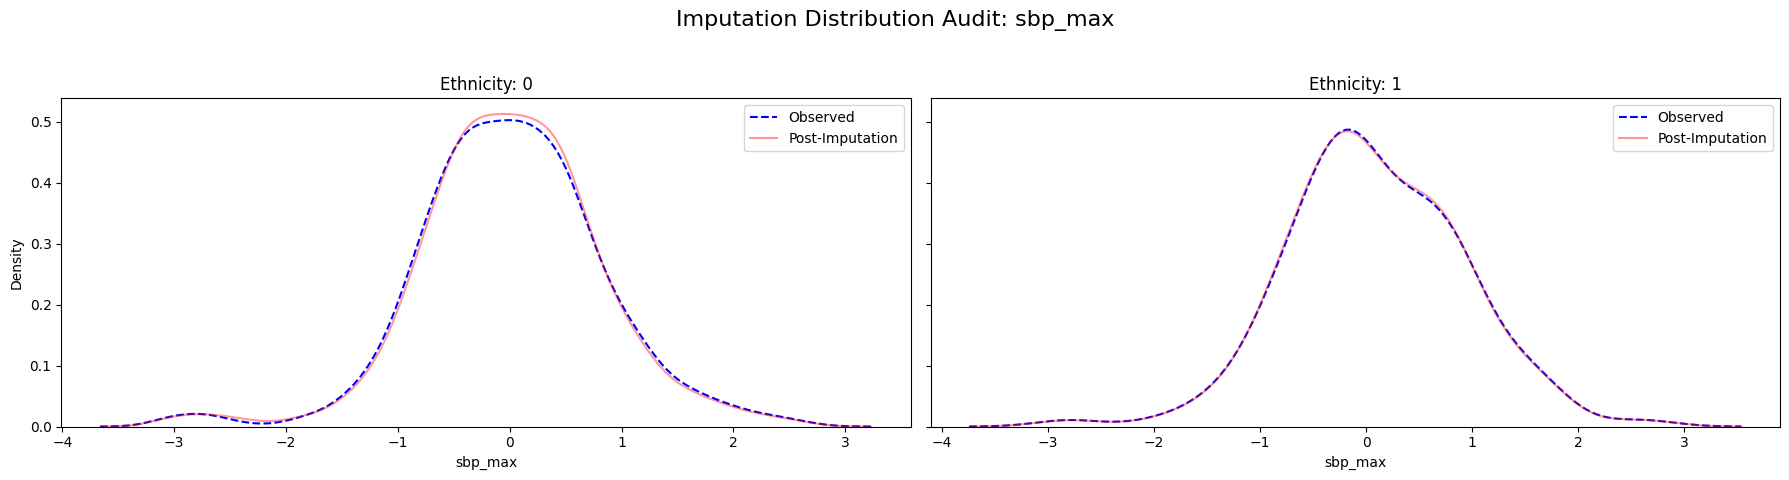

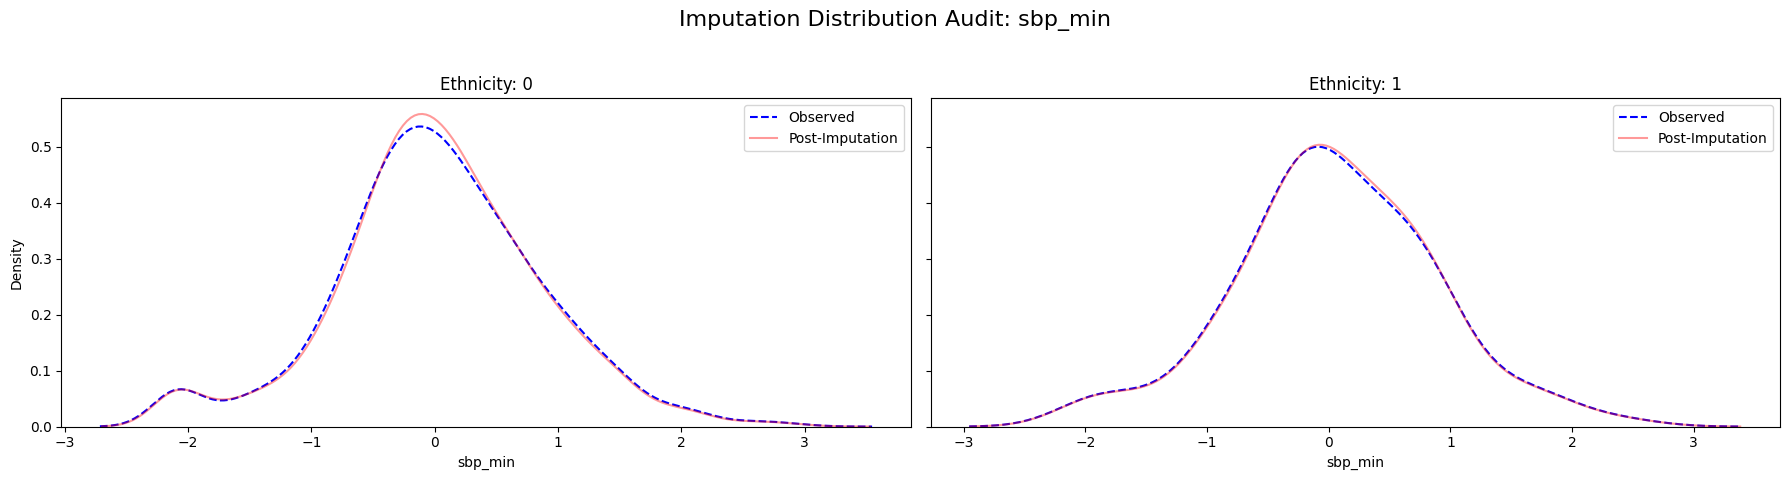

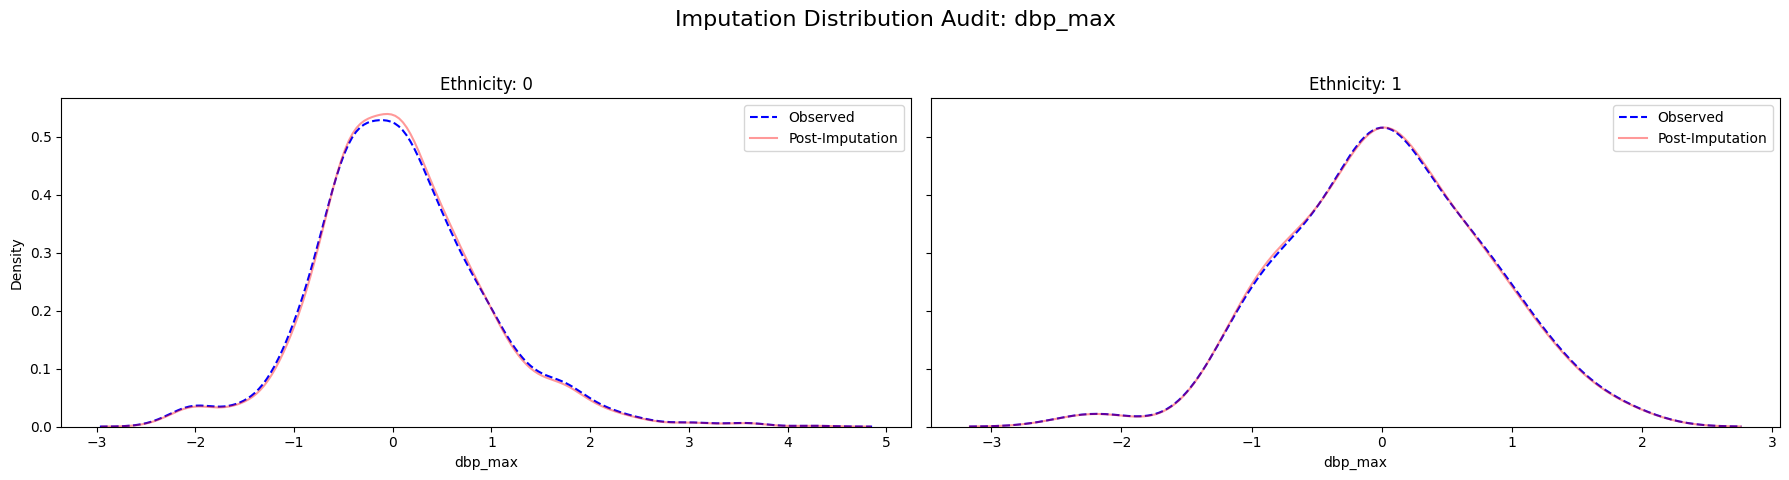

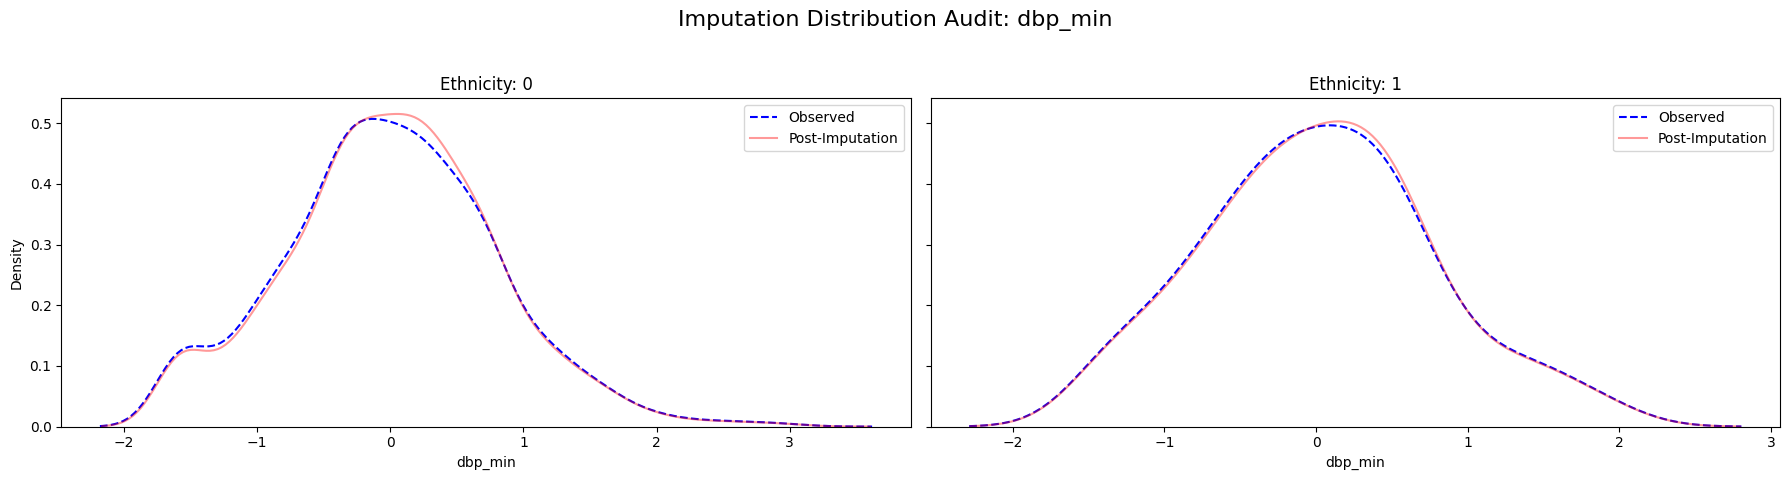

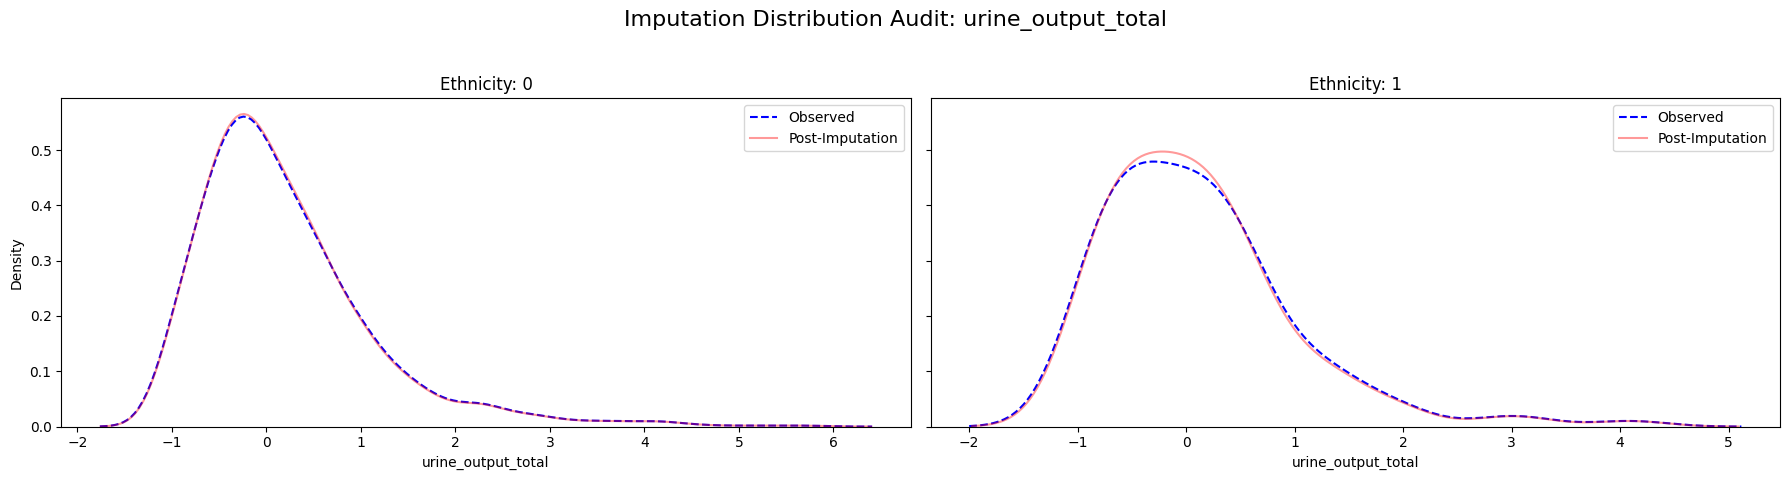

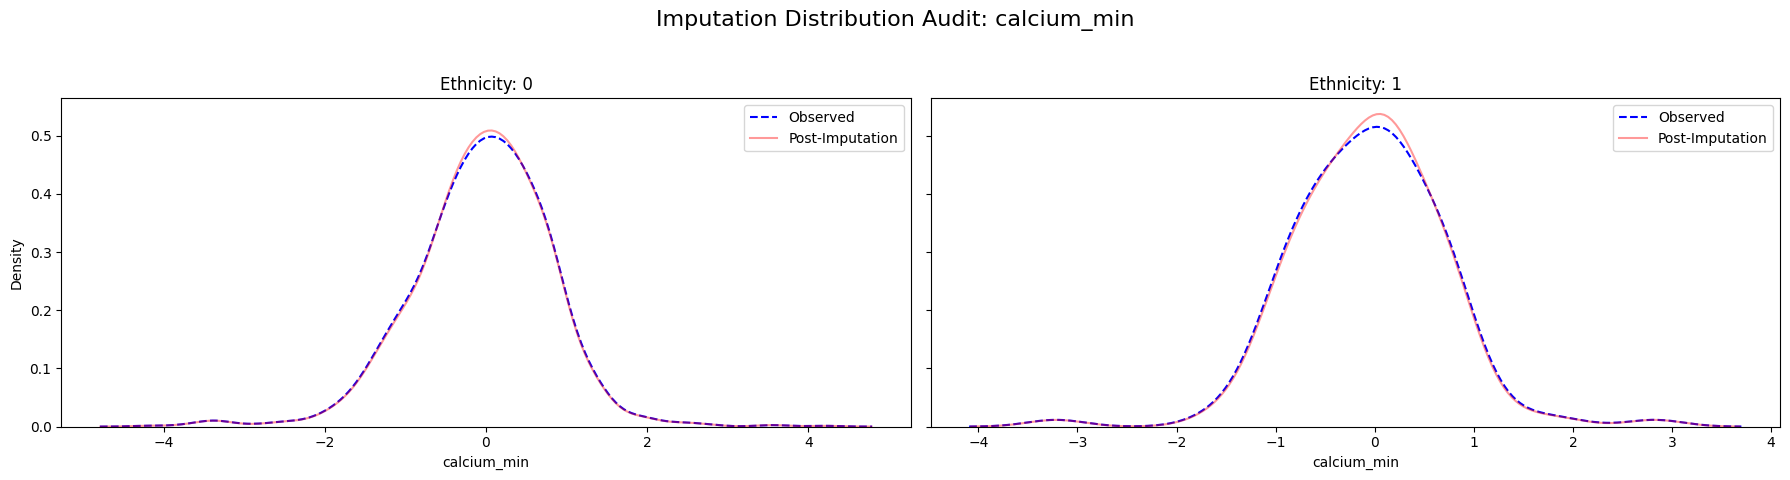

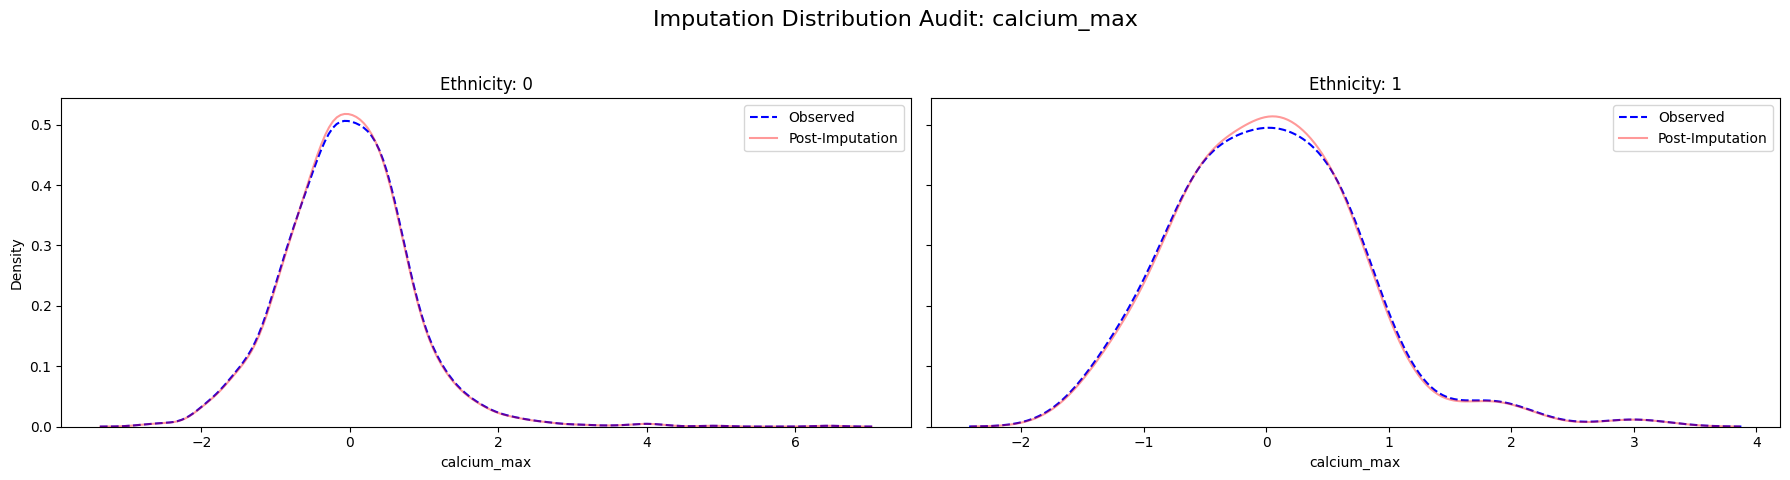

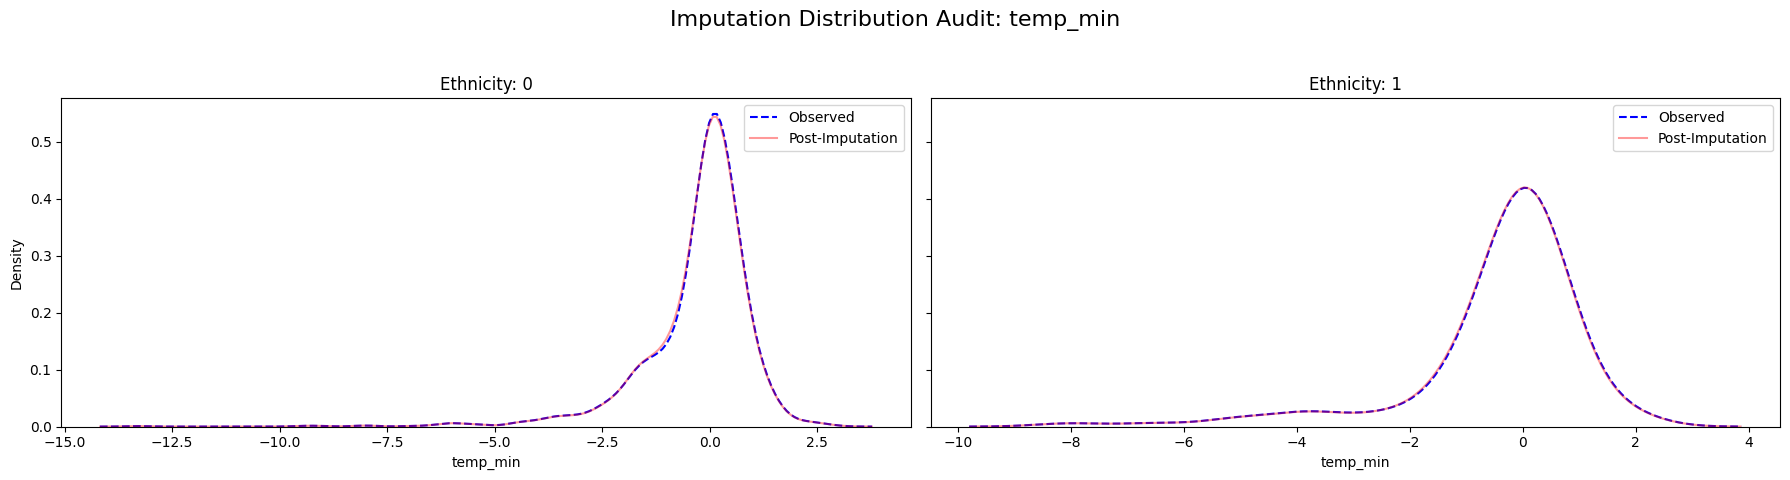

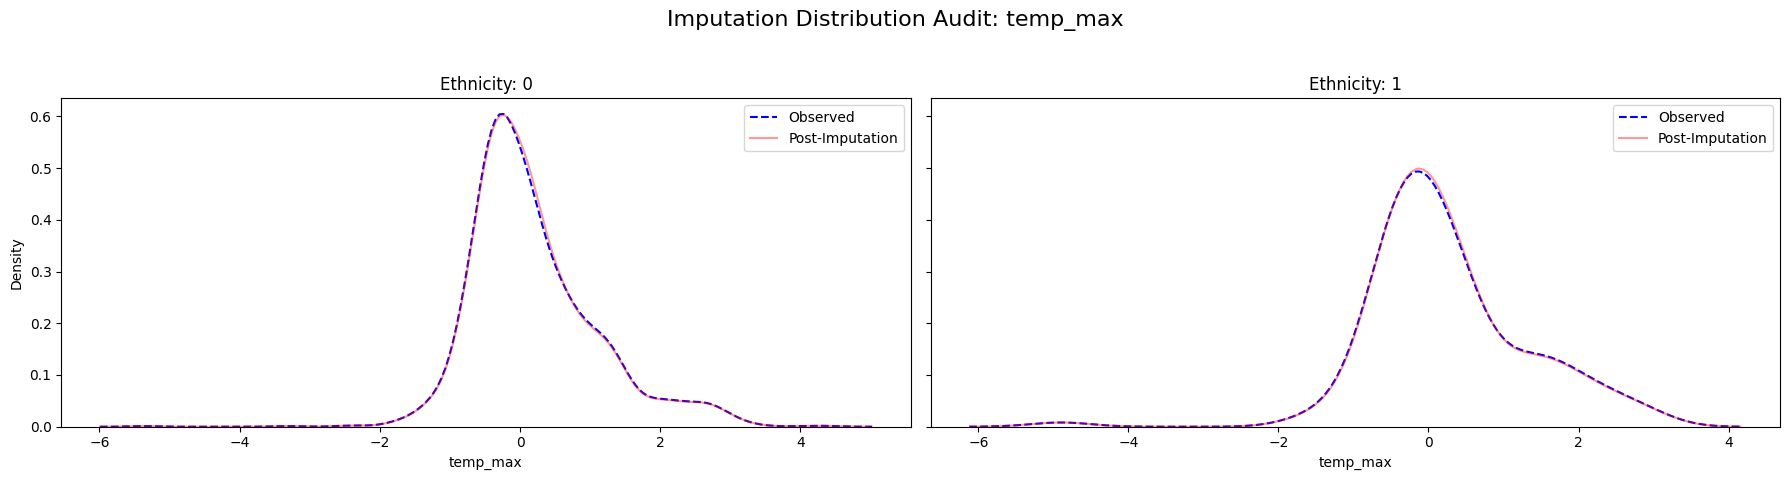

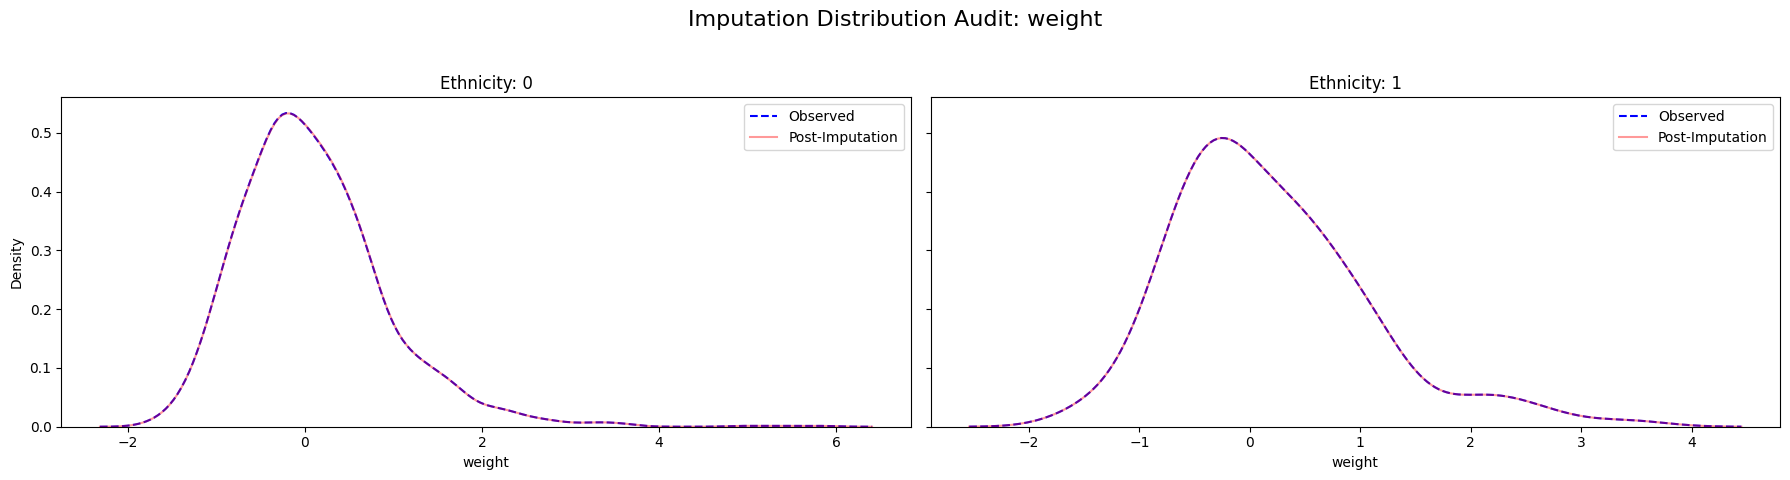

In [27]:
for col in train_top_missing_cols:
  audit_ethnic_imputation(scaled_train_df, imputed_train_dataset, col, ethnicities)

In [28]:
bias_df = calculate_imputation_shift(scaled_train_df, imputed_train_dataset, train_top_missing_cols)
significant_bias = bias_df[bias_df['Internal SMD'].abs() > 0.01]
print(significant_bias.to_markdown(index=False))

|   Ethnicity | Feature            |   Observed Mean |   Imputed Mean |   Internal SMD |   Global SMD |
|------------:|:-------------------|----------------:|---------------:|---------------:|-------------:|
|           0 | dbp_min            |    -0.000799663 |      0.0115656 |      0.0154535 |    0.0133635 |
|           1 | urine_output_total |     0.1183      |      0.108555  |     -0.0110118 |   -0.0975459 |


### TEST split

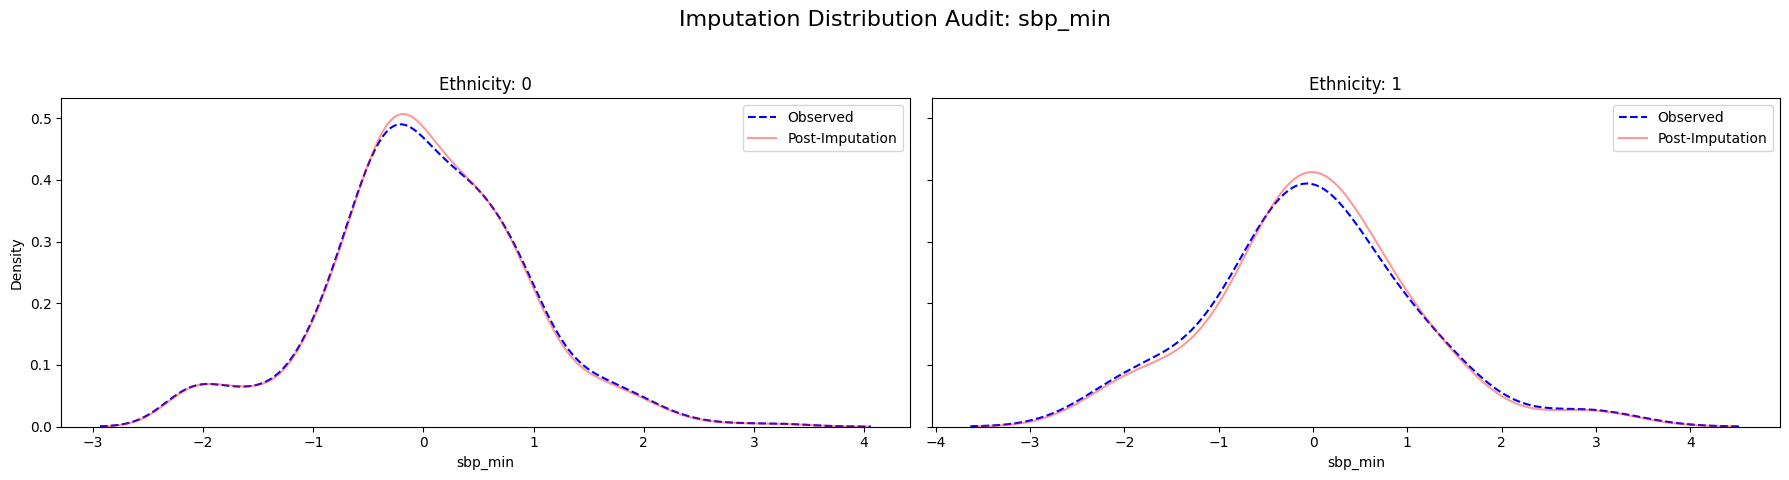

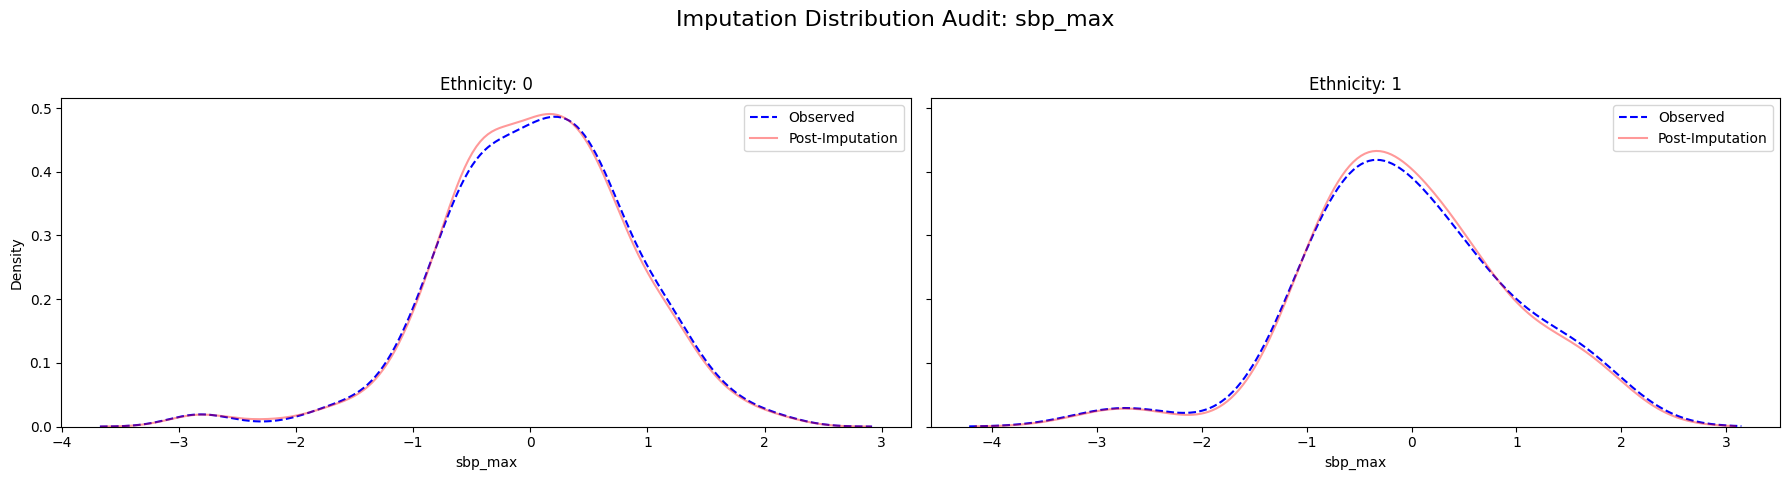

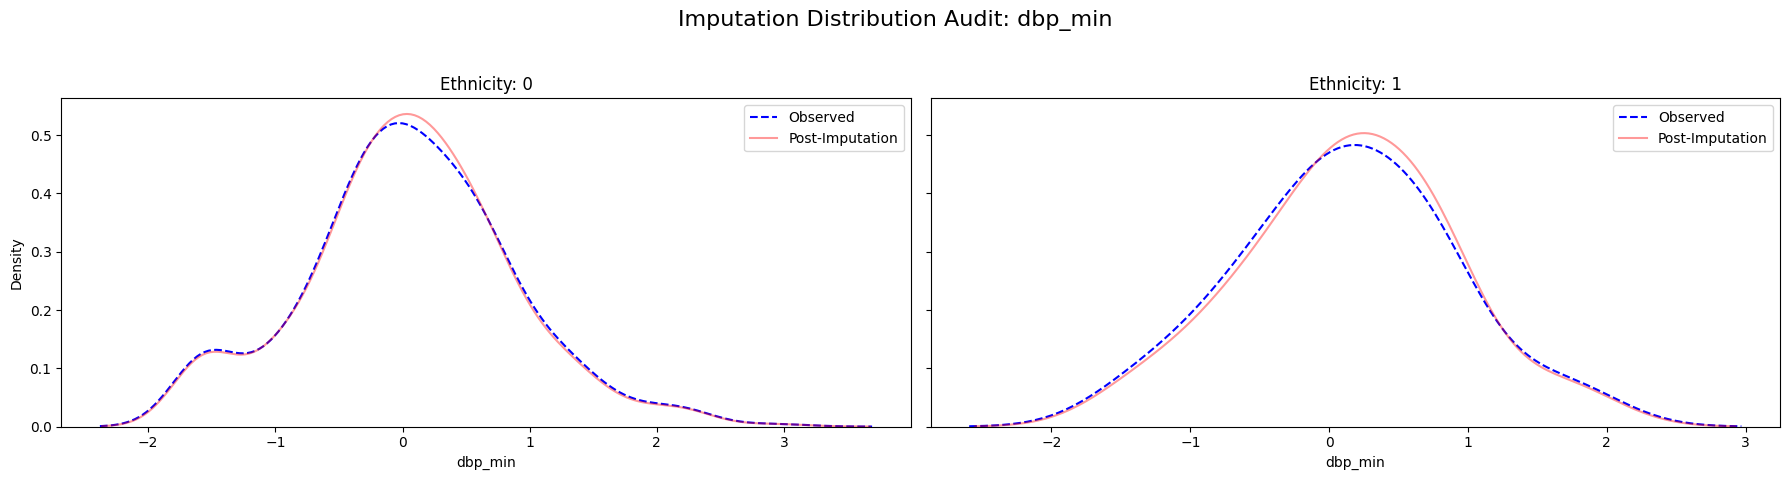

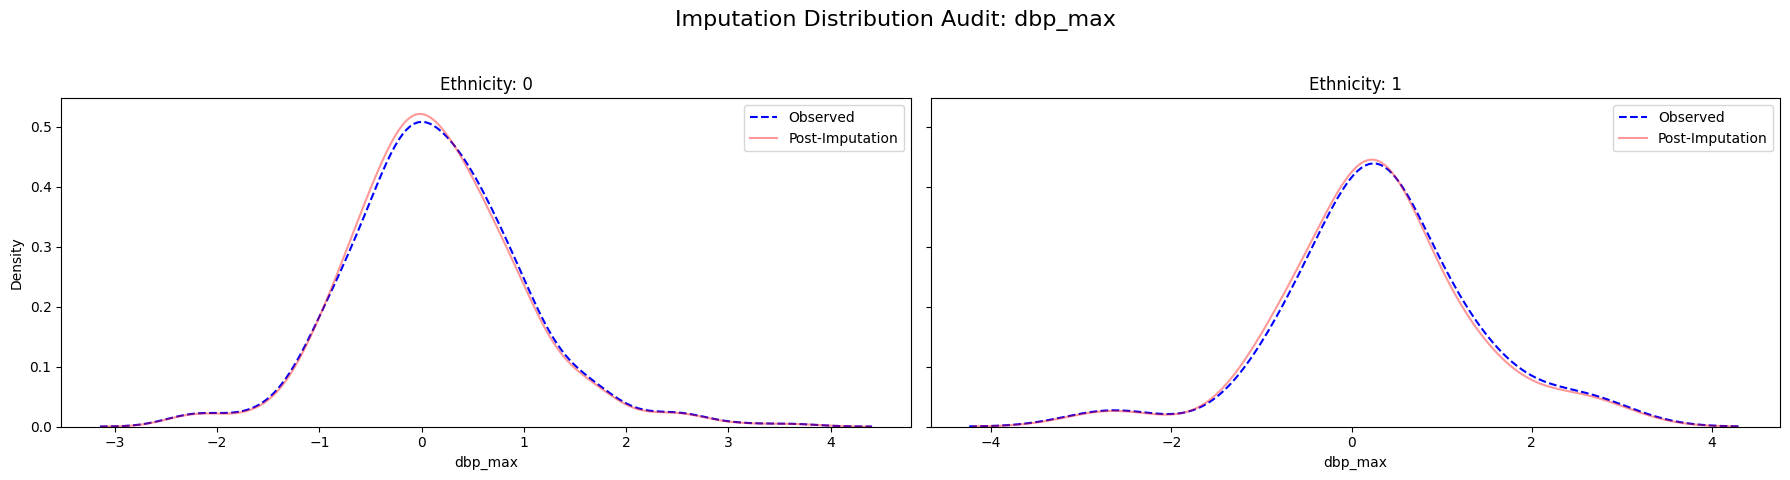

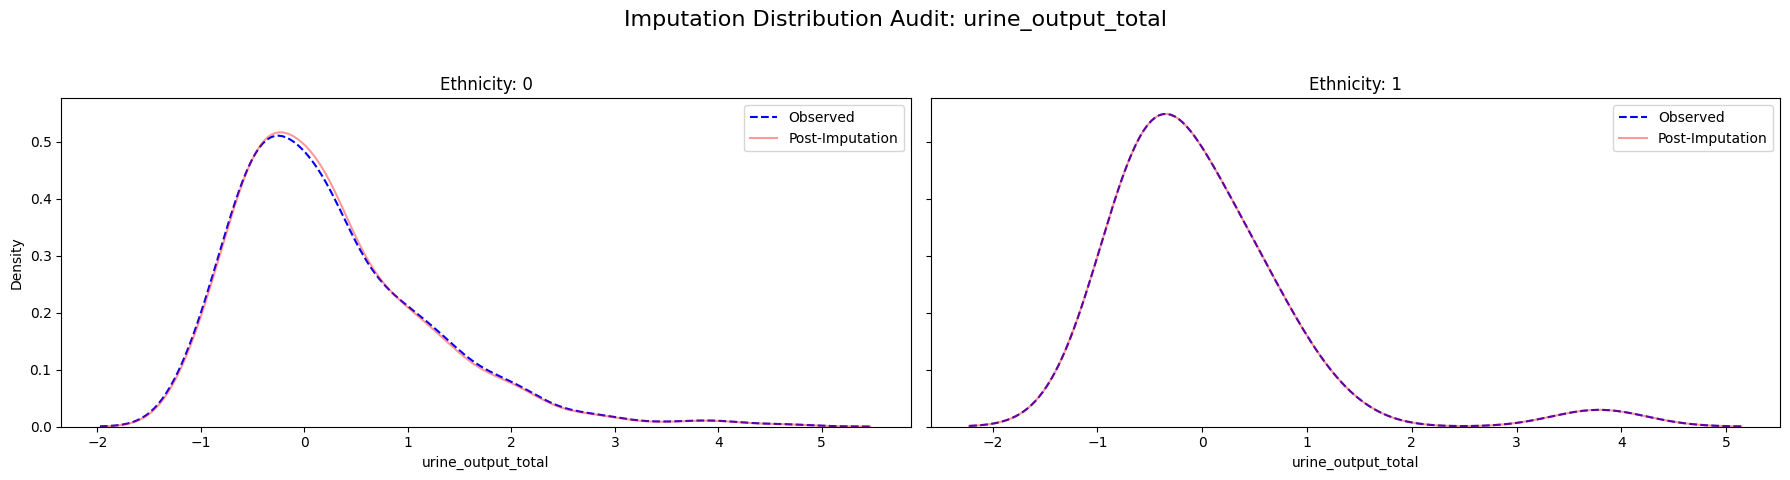

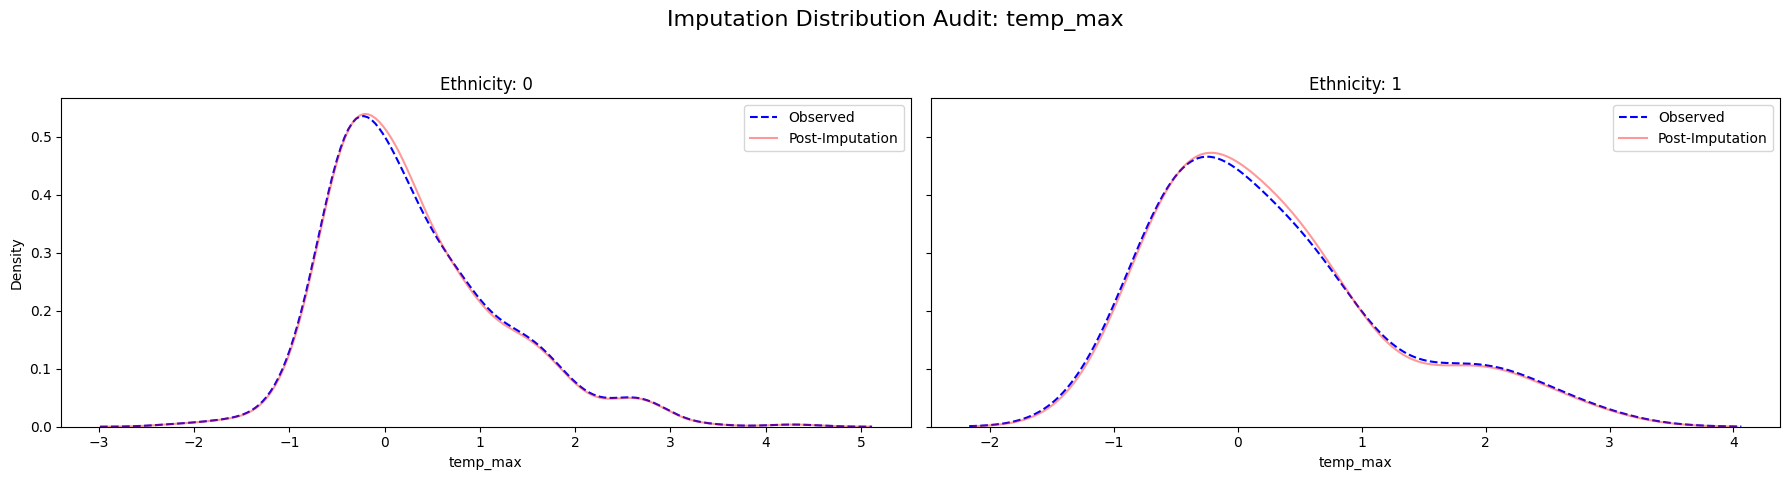

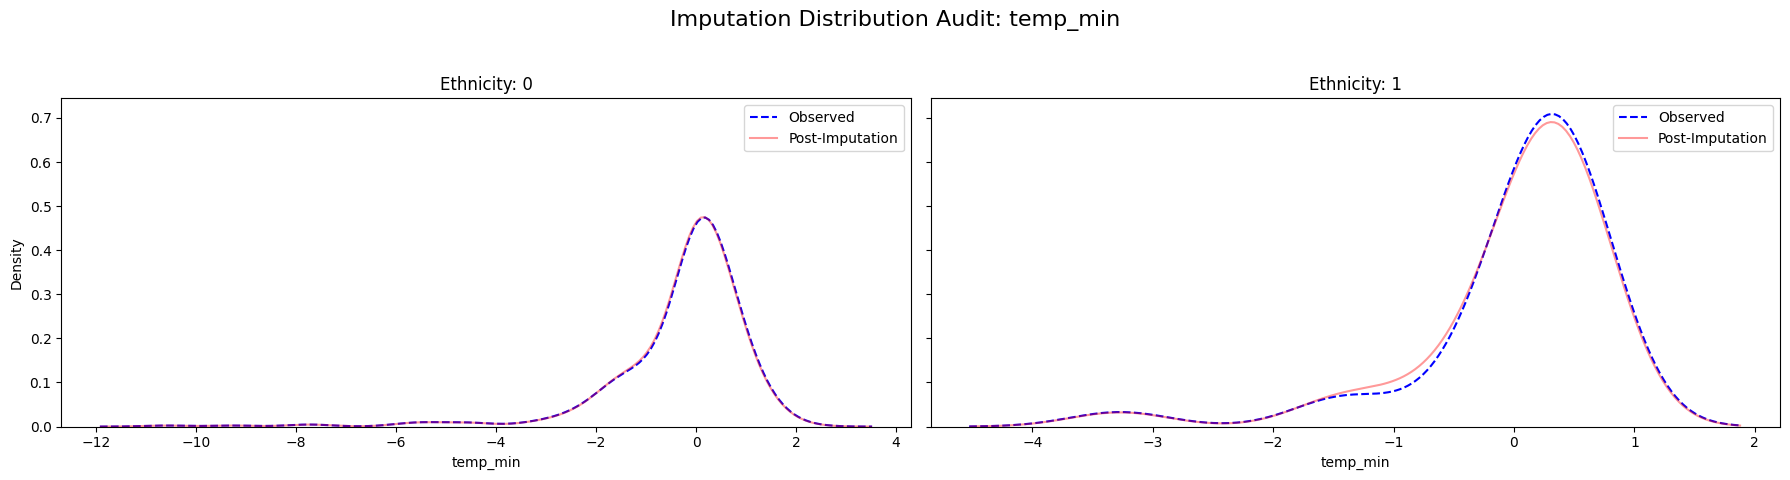

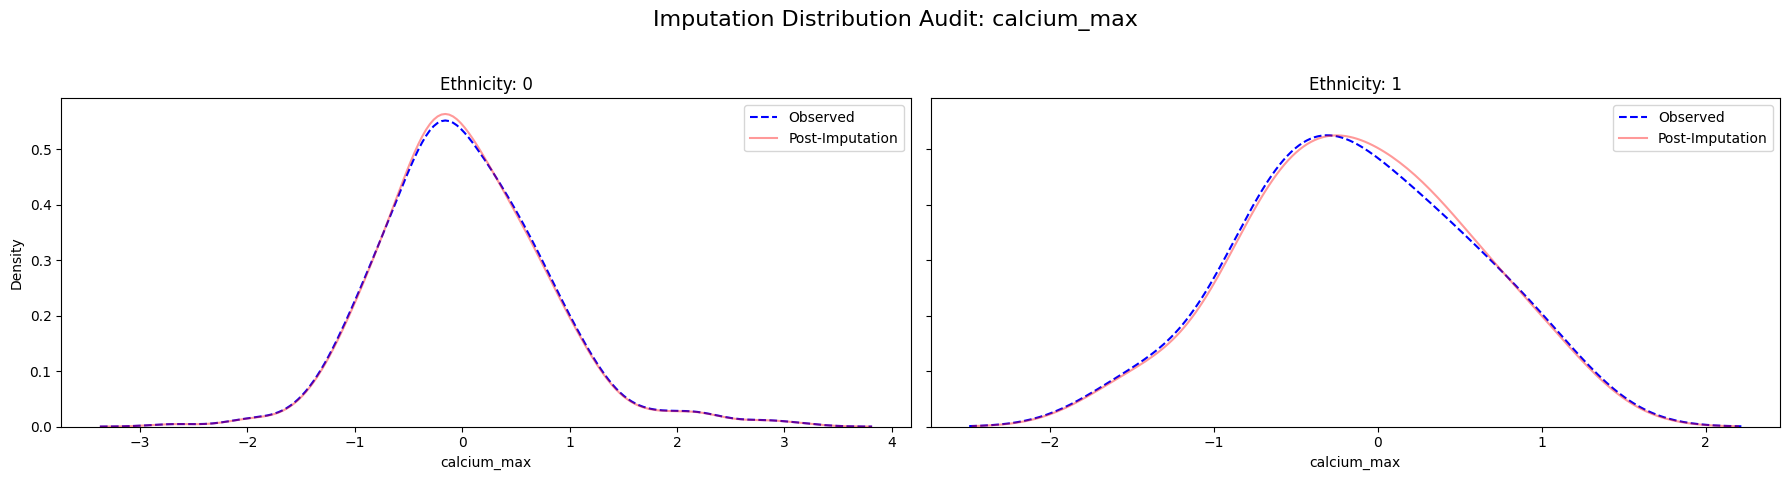

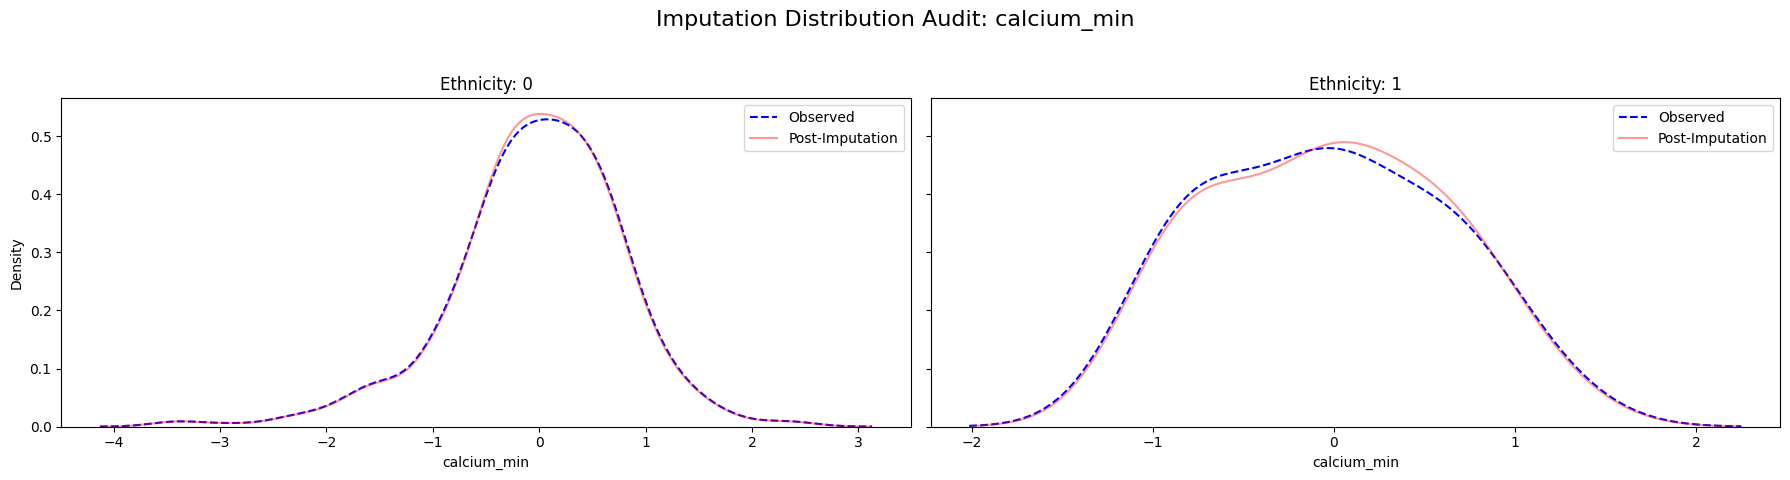

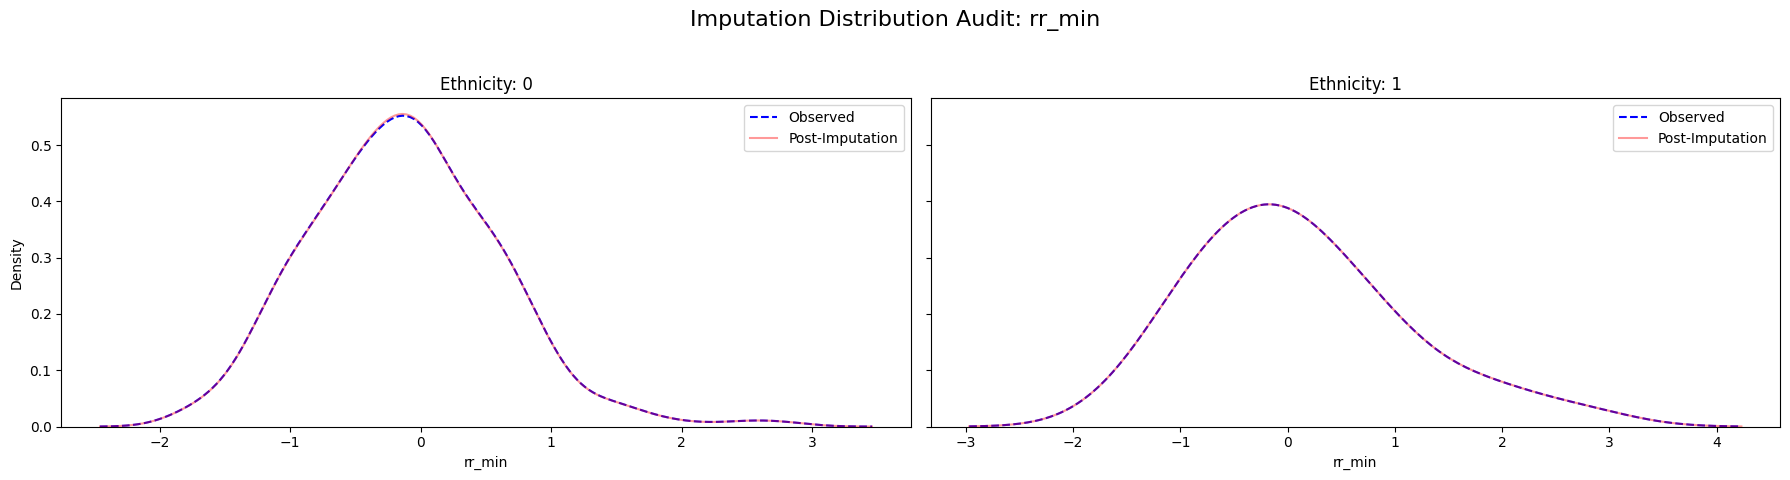

In [29]:
for col in test_top_missing_cols:
  audit_ethnic_imputation(scaled_test_df, imputed_test_dataset, col, ethnicities)

In [30]:
bias_df = calculate_imputation_shift(scaled_test_df, imputed_test_dataset, test_top_missing_cols)
significant_bias = bias_df[bias_df['Internal SMD'].abs() > 0.01]
print(significant_bias.to_markdown(index=False))

|   Ethnicity | Feature     |   Observed Mean |   Imputed Mean |   Internal SMD |   Global SMD |
|------------:|:------------|----------------:|---------------:|---------------:|-------------:|
|           0 | sbp_max     |       0.0610871 |     0.0463058  |     -0.0183713 |  -0.00923093 |
|           0 | dbp_max     |       0.13906   |     0.122646   |     -0.0193663 |  -0.0336366  |
|           1 | sbp_min     |      -0.0012987 |     0.0193605  |      0.0194922 |   0.00247125 |
|           1 | dbp_min     |       0.12605   |     0.15044    |      0.0318223 |   0.122057   |
|           1 | dbp_max     |       0.314869  |     0.27416    |     -0.0394152 |   0.119098   |
|           1 | temp_min    |       0.031348  |     0.00511691 |     -0.0320422 |   0.334276   |
|           1 | calcium_max |      -0.128527  |    -0.117822   |      0.0158109 |  -0.180499   |
|           1 | calcium_min |      -0.040568  |    -0.027846   |      0.0195513 |  -0.0126605  |


# Save splits

In [31]:
imputed_test_dataset.to_csv(f"{PROJECT_ROOT}/{Config.DATA_DIR}/mimic_iv_test.csv")
imputed_train_dataset.to_csv(f"{PROJECT_ROOT}/{Config.DATA_DIR}/mimic_iv_train.csv")

In [37]:
# TRAIN split: Descriptive statistics
table1 = TableOne(imputed_train_dataset,
                  groupby='race_group',
                  continuous=continuous_features,
                  missing=False
                  )

print(table1)

                                             Grouped by race_group                           
                                                           Overall             0            1
n                                                             1704          1582          122
gender, n (%)                            0              929 (54.5)    861 (54.4)    68 (55.7)
                                         1              775 (45.5)    721 (45.6)    54 (44.3)
admission_age, mean (SD)                                -0.1 (0.8)    -0.0 (0.7)   -0.2 (0.9)
hr_min, mean (SD)                                        0.1 (0.8)     0.1 (0.8)    0.2 (0.8)
hr_max, mean (SD)                                        0.1 (0.8)     0.1 (0.8)    0.1 (0.8)
rr_min, mean (SD)                                       -0.1 (0.7)    -0.1 (0.7)    0.1 (0.8)
rr_max, mean (SD)                                        0.2 (0.8)     0.2 (0.8)    0.1 (0.9)
sbp_min, mean (SD)                                       0.0

In [38]:
# TEST split: Descriptive statistics
table1 = TableOne(imputed_test_dataset,
                  groupby='race_group',
                  continuous=continuous_features,
                  missing=False
                  )

print(table1)

                                             Grouped by race_group                         
                                                           Overall            0           1
n                                                              426          396          30
gender, n (%)                            0              227 (53.3)   213 (53.8)   14 (46.7)
                                         1              199 (46.7)   183 (46.2)   16 (53.3)
admission_age, mean (SD)                                -0.1 (0.8)   -0.1 (0.8)  -0.5 (0.7)
hr_min, mean (SD)                                        0.0 (0.7)    0.0 (0.7)   0.2 (0.7)
hr_max, mean (SD)                                        0.1 (0.8)    0.1 (0.8)   0.3 (0.9)
rr_min, mean (SD)                                       -0.1 (0.7)   -0.1 (0.7)   0.1 (1.0)
rr_max, mean (SD)                                        0.1 (0.8)    0.1 (0.8)   0.1 (0.8)
sbp_min, mean (SD)                                       0.0 (0.9)    0.0 (0.9) 